# Download and prepare `TA` (2004-2025)

**notebook version**: `2` (19 Jul 2026)

## ℹ️ About this notebook

Downloads screened air temperature `TA` from the InfluxDB database, merges the data sources into
one continuous series, corrects the known August 2012 logger timestamp shift, gap-fills the result
and stores it to the external data folder.

This notebook follows the same structure as notebook `01` (`SW_IN`), with one deliberate
difference in the gap-filling, explained in the gap-filling section below.

**Output columns:**

- `TA_T1_47_1_gfXG` — the gap-filled series (°C, complete)
- `FLAG_TA_T1_47_1_ISFILLED` — how each record was obtained; `0` = measured, `>0` = filled
  (see `FLAG_LEGEND` below for the individual codes)

Downloading uses diive's in-house InfluxDB engine `InfluxIO`. It needs `influxdb-client`, which
a plain `uv sync` installs here via the `diive[db]` extra.

***

# Info about data sources

- `TA`: NABEL (`TA_NABEL_T1_49_1`) and ETH (`TA_T1_47_1`)
- ETH data are the main data
- NABEL data are used as an additional driver where they are available
- The gap-filled `SW_IN` from notebook `01` is used as a driver over the whole record

Legend:
- NABEL ... Data from [NABEL](https://www.bafu.admin.ch/bafu/en/home/topics/air/luftbelastung/national-air-pollution-monitoring-network--nabel-.html), meteoscreening with [diive](https://github.com/holukas/diive)
- mst ... Data from ETH, meteoscreening with the now deprecated MeteoscreeningTool
- diive ... Data from ETH, meteoscreening with diive

## ⏱️ Timestamp convention

The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`**. On download, `InfluxIO`
shifts the UTC timestamp by `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the returned data are in **local
time** (UTC + offset) and still `TIMESTAMP_END`. `TimestampSanitizer(output_middle_timestamp=True)`
then converts to `TIMESTAMP_MID`, which is what the rest of this notebook works with.

`START` and `STOP` are interpreted in the same timezone as `TIMEZONE_OFFSET_TO_UTC_HOURS`.

***

# ⚙️ Settings

## Data settings

In [1]:
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'  # Folder with configuration files
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # Timezone, e.g. "1" is translated to timezone "UTC+01:00" (CET, winter time)
REQUIRED_TIME_RESOLUTION = '30min'  # Expected resolution; TimestampSanitizer raises if the data disagree
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

# Output: data files live in the external (untracked) data folder, with the same
# numeric prefix as this notebook.
OUTNAME = "02_METEO_TA_GAPFILLED_2004-2025"
OUTPATH = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"

# Gap-filled SW_IN produced by notebook 01, used here as a driver.
SWIN_FILE = "01_METEO_SW_IN_GAPFILLED_2004-2025"
SWIN_COL = "SW_IN_T1_47_1_gfXG"

## Imports

In [2]:
from datetime import datetime
from pathlib import Path
import importlib.metadata

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme('notebook')

import diive as dv
from diive.core.io.db.influx import InfluxIO  # diive's in-house InfluxDB engine (via the diive[db] extra)
from diive.core.times.times import TimestampSanitizer

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

# Start time is kept so the last cell can report the total runtime of the notebook.
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")

Last run: 2026-07-19 23:27:25
diive version: v0.91.0


In [3]:
# Result flags used in this notebook.
# 0/1/2 are the standard diive gap-filling flags (see GapFillingResult). 4 is added by the
# short-gap interpolation step below and uses the same code as in notebook 01, so both
# products speak the same language. There is no flag 3 here: that is the nighttime-zero
# branch of the SW_IN gap-filler, which does not apply to temperature.
FLAG_LEGEND = {
    0: '0 = observed',
    1: '1 = gap-filled by the XGBoost model',
    2: '2 = gap-filled by the timestamp-only fallback model (a driver was missing)',
    4: '4 = gap-filled by linear interpolation (short gap)',
}

## 🔌 Connect to database

In [4]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

***

# ⬇️ `NABEL` and ETH data from `diive` meteoscreening

## Download

In [5]:
%%time

BUCKET = f'ch-lae_processed'
FIELDS = ['TA_NABEL_T1_49_1', 'TA_T1_47_1']
MEASUREMENTS = ['TA']
START = '2004-01-01 00:00:01'
STOP = '2026-01-01 00:00:01'
DATA_VERSION = 'meteoscreening_diive'

nabel_eth_diive_ta, _, _ = dbc.download(
    bucket=BUCKET,
    measurements=MEASUREMENTS,
    fields=FIELDS,
    start=START,  # Download data starting with this date (the start date itself IS included),
    stop=STOP,  # Download data before this date (the stop date itself IS NOT included),
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION
)

> DOWNLOADING from bucket ch-lae_processed: variables ['TA_NABEL_T1_49_1', 'TA_T1_47_1'] from 
measurements ['TA'], data version ['meteoscreening_diive'], between 2004-01-01 00:00:01 and 
2026-01-01 00:00:01 (timezone offset to UTC 1)

> Downloaded data for 2 variables:

CPU times: total: 6.11 s
Wall time: 8.55 s


In [6]:
nabel_eth_diive_ta

,TA_T1_47_1,TA_NABEL_T1_49_1
TIMESTAMP_END,,
2004-01-01 00:30:00,NaN,-2.666667
2004-01-01 01:00:00,NaN,-2.566667
2004-01-01 01:30:00,NaN,-2.533333
2004-01-01 02:00:00,NaN,-2.633333
2004-01-01 02:30:00,NaN,-2.800000
...,...,...
2025-12-31 22:00:00,-3.081644,NaN
2025-12-31 22:30:00,-3.084372,NaN
2025-12-31 23:00:00,-3.423939,NaN


## Sanitize timestamp

In [7]:
nabel_eth_diive_ta = TimestampSanitizer(
    data=nabel_eth_diive_ta,
    output_middle_timestamp=True,
    nominal_freq=REQUIRED_TIME_RESOLUTION,  # raises ValueError if the data are not 30MIN
).get()
nabel_eth_diive_ta

,TA_T1_47_1,TA_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,-2.666667
2004-01-01 00:45:00,NaN,-2.566667
2004-01-01 01:15:00,NaN,-2.533333
2004-01-01 01:45:00,NaN,-2.633333
2004-01-01 02:15:00,NaN,-2.800000
...,...,...
2025-12-31 21:45:00,-3.081644,NaN
2025-12-31 22:15:00,-3.084372,NaN
2025-12-31 22:45:00,-3.423939,NaN


***

# ⬇️ Data from `mst` meteoscreening

## Download

In [8]:
%%time

BUCKET = f'ch-lae_processed'
FIELDS = ['TA_T1_47_1']
MEASUREMENTS = ['TA']
START = '2004-01-01 00:00:01'
STOP = '2022-01-01 00:00:01'
DATA_VERSION = 'meteoscreening_mst'

mst_ta, _, _ = dbc.download(
    bucket=BUCKET,
    measurements=MEASUREMENTS,
    fields=FIELDS,
    start=START,
    stop=STOP,
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION
)

> DOWNLOADING from bucket ch-lae_processed: variables ['TA_T1_47_1'] from measurements ['TA'], 
data version ['meteoscreening_mst'], between 2004-01-01 00:00:01 and 2022-01-01 00:00:01 (timezone 
offset to UTC 1)

> Downloaded data for 1 variables:

CPU times: total: 4.91 s
Wall time: 7.23 s


In [9]:
mst_ta

,TA_T1_47_1
TIMESTAMP_END,
2004-09-20 11:00:00,13.300000
2004-09-20 11:30:00,13.390000
2004-09-20 12:00:00,13.810000
2004-09-20 12:30:00,14.470000
2004-09-20 13:00:00,13.980000
...,...
2021-12-31 22:00:00,7.933211
2021-12-31 22:30:00,8.022416
2021-12-31 23:00:00,7.719400


## Sanitize timestamp

In [10]:
mst_ta = TimestampSanitizer(
    data=mst_ta,
    output_middle_timestamp=True,
    nominal_freq=REQUIRED_TIME_RESOLUTION,
).get()
mst_ta

,TA_T1_47_1
TIMESTAMP_MIDDLE,
2004-09-20 10:45:00,13.300000
2004-09-20 11:15:00,13.390000
2004-09-20 11:45:00,13.810000
2004-09-20 12:15:00,14.470000
2004-09-20 12:45:00,13.980000
...,...
2021-12-31 21:45:00,7.933211
2021-12-31 22:15:00,8.022416
2021-12-31 22:45:00,7.719400


***

# ❇️ Merge data

Data from `diive` meteoscreening are the main data, remaining gaps are filled in from the `mst`
meteoscreening. Both variables are merged the same way.

In [11]:
ta_2004_2025 = nabel_eth_diive_ta.copy()

for col in ['TA_T1_47_1', 'TA_NABEL_T1_49_1']:
    if col in mst_ta.columns:
        before = ta_2004_2025[col].notna().sum()
        ta_2004_2025[col] = ta_2004_2025[col].combine_first(mst_ta[col])
        after = ta_2004_2025[col].notna().sum()
        print(f"{col}: {before:,} -> {after:,} records ({after - before:,} added from mst)")

ta_2004_2025

TA_T1_47_1: 70,012 -> 370,280 records (300,268 added from mst)


,TA_T1_47_1,TA_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,-2.666667
2004-01-01 00:45:00,NaN,-2.566667
2004-01-01 01:15:00,NaN,-2.533333
2004-01-01 01:45:00,NaN,-2.633333
2004-01-01 02:15:00,NaN,-2.800000
...,...,...
2025-12-31 21:45:00,-3.081644,NaN
2025-12-31 22:15:00,-3.084372,NaN
2025-12-31 22:45:00,-3.423939,NaN


## Sanitize timestamp

In [12]:
ta_2004_2025 = TimestampSanitizer(data=ta_2004_2025, output_middle_timestamp=True).get()
ta_2004_2025

,TA_T1_47_1,TA_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,-2.666667
2004-01-01 00:45:00,NaN,-2.566667
2004-01-01 01:15:00,NaN,-2.533333
2004-01-01 01:45:00,NaN,-2.633333
2004-01-01 02:15:00,NaN,-2.800000
...,...,...
2025-12-31 21:45:00,-3.081644,NaN
2025-12-31 22:15:00,-3.084372,NaN
2025-12-31 22:45:00,-3.423939,NaN


## Heatmap

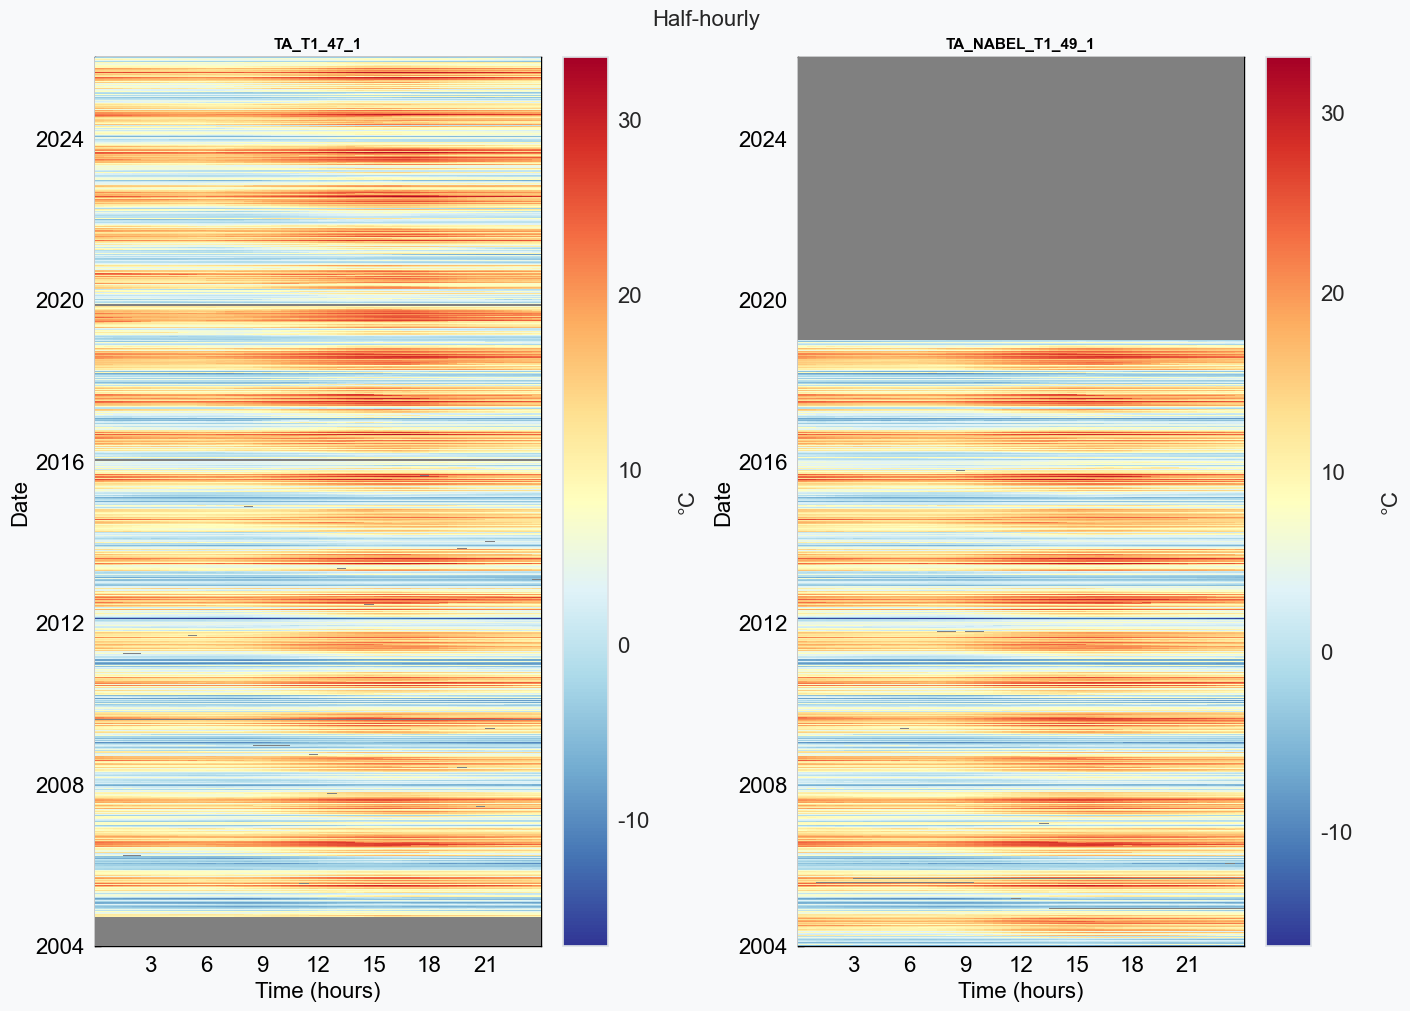

In [13]:
fig, axs = plt.subplots(ncols=2, figsize=(14, 10), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.plotting.HeatmapDateTime(series=ta_2004_2025['TA_T1_47_1']).plot(
    ax=axs[0], cb_digits_after_comma=0, zlabel='°C',
    format_style=dv.plotting.FormatStyle(title="TA_T1_47_1", title_fontsize=11))
dv.plotting.HeatmapDateTime(series=ta_2004_2025['TA_NABEL_T1_49_1']).plot(
    ax=axs[1], cb_digits_after_comma=0, zlabel='°C',
    format_style=dv.plotting.FormatStyle(title="TA_NABEL_T1_49_1", title_fontsize=11))

***

# ✴️ Corrections

### Timestamp shift in August 2012
**Info from fieldbook entry 17 Aug 2012:**
>   adjusted the logger date and time. On Servertime (Computer System Time) 17.08.2012 12:31.42 the loggertime was 16.08.2012 08:06:00. Synchronized time at 17.08.2012 11:40:00 servertime. The logger data aquisition on the moxa embedded was restarted

This is a clock error of the logger, so it affects every variable that logger recorded, not just
radiation. The same correction as in notebook `01` is applied here to `TA_T1_47_1`. The heatmaps
below show the diurnal pattern before and after, which is the visual check that the shift is right:
after the correction the warm band has to sit around midday again.

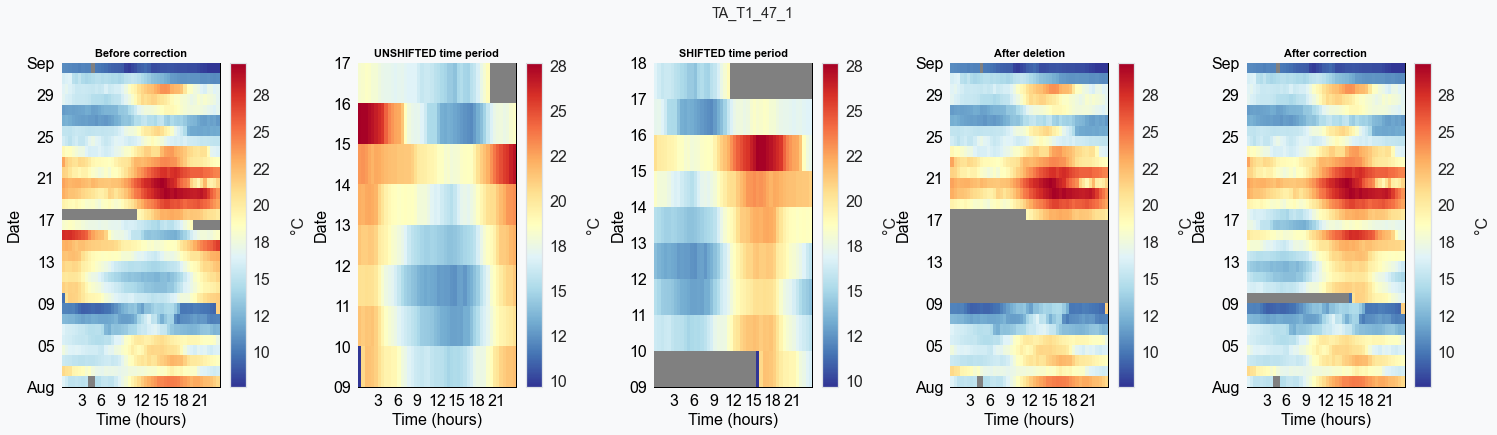

In [14]:
AFFECTED_VARS = ['TA_T1_47_1']
_df = ta_2004_2025.copy()

for av in AFFECTED_VARS:
    fig = plt.figure(figsize=(24, 6), dpi=72)
    fig.suptitle(f"{av}")
    gs = gridspec.GridSpec(1, 5)  # rows, cols
    gs.update(wspace=0.5, hspace=1, left=.1, right=.9, top=.85, bottom=.1)
    ax_before = fig.add_subplot(gs[0, 0])
    ax_unshifted = fig.add_subplot(gs[0, 1])
    ax_shifted = fig.add_subplot(gs[0, 2])
    ax_after = fig.add_subplot(gs[0, 3])
    ax_corrected = fig.add_subplot(gs[0, 4])

    # Show time period around issue, before correction
    _show_locs = (_df.index >= '2012-08-01 00:00') & (_df.index <= '2012-09-01 00:00')
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_before, cb_digits_after_comma=0, zlabel='°C',
        format_style=dv.plotting.FormatStyle(title="Before correction", title_fontsize=11))

    # Get shifted time period
    _series_corrected = _df.loc[_show_locs, av].copy()
    # Identify shifted time period
    ISSUE_START = '2012-08-09 00:00'
    ISSUE_END = '2012-08-17 00:00'
    _shifted_locs = (_df.index >= ISSUE_START) & (_df.index <= ISSUE_END)
    _series_shifted = _df.loc[_shifted_locs, av].copy()
    _series_shifted = _series_shifted.dropna()
    dv.plotting.HeatmapDateTime(series=_series_shifted).plot(
        ax=ax_unshifted, cb_digits_after_comma=0, zlabel='°C',
        format_style=dv.plotting.FormatStyle(title="UNSHIFTED time period", title_fontsize=11))

    # Shift by 15.5 hours during shifted time period, create corrected time series
    _series_shifted.index = _series_shifted.index + pd.Timedelta(hours=15.5)
    dv.plotting.HeatmapDateTime(series=_series_shifted).plot(
        ax=ax_shifted, cb_digits_after_comma=0, zlabel='°C',
        format_style=dv.plotting.FormatStyle(title="SHIFTED time period", title_fontsize=11))

    # Delete data between start of issue and the last timestamp of shifted data
    _overwrite_locs = (_df.index >= ISSUE_START) & (_df.index <= _series_shifted.index[-1])
    _df.loc[_overwrite_locs, av] = np.nan
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_after, cb_digits_after_comma=0, zlabel='°C',
        format_style=dv.plotting.FormatStyle(title="After deletion", title_fontsize=11))

    # Fill in corrected values
    _df.loc[_overwrite_locs, av] = _series_shifted
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_corrected, cb_digits_after_comma=0, zlabel='°C',
        format_style=dv.plotting.FormatStyle(title="After correction", title_fontsize=11))

In [15]:
ta_2004_2025 = _df.copy()
ta_2004_2025

,TA_T1_47_1,TA_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,-2.666667
2004-01-01 00:45:00,NaN,-2.566667
2004-01-01 01:15:00,NaN,-2.533333
2004-01-01 01:45:00,NaN,-2.633333
2004-01-01 02:15:00,NaN,-2.800000
...,...,...
2025-12-31 21:45:00,-3.081644,NaN
2025-12-31 22:15:00,-3.084372,NaN
2025-12-31 22:45:00,-3.423939,NaN


### Power failure, late July to mid August 2012

The clock shift above is not the only damage in August 2012. Aligning `TA_T1_47_1` against the
NABEL sensor day by day, and searching for the lag that agrees best (baseline agreement between
the two sensors is 0.7-0.9 degC):

| date | best lag | RMSE at best lag | RMSE at zero lag |
|---|---|---|---|
| 2012-07-27 | 0 | 0.76 | 0.76 |
| 2012-07-30 | -24.0 h | 2.51 | 3.06 |
| 2012-08-01 | -1.0 h | 3.22 | 3.31 |
| 2012-08-06 | +1.5 h | 2.49 | 2.53 |
| 2012-08-08 | -35.5 h | 2.85 | 4.95 |
| 2012-08-09 | -33.0 h | 1.19 | 5.30 |
| **2012-08-11** | **+15.5 h** | **0.78** | 5.01 |
| **2012-08-14** | **+15.5 h** | **0.69** | 6.04 |
| **2012-08-16** | **+15.5 h** | **0.84** | 6.00 |
| 2012-08-17 | -0.5 h | 1.65 | 1.69 |
| 2012-08-18 | 0 | 0.64 | 0.64 |

- **11 to 16 August** locks onto `+15.5 h` and returns to the normal 0.7-0.8 degC agreement. That
  is the logger clock, corrected above. `SW_IN` shows the shift on the same days.
- **29 July to 9 August** stays at 1.2-3.2 degC whatever lag is applied. The apparent best lags of
  around +/-24 h are aliases, since shifting a daily cycle by about a day roughly realigns it.

The fieldbook gives the cause, and dates the repair to the day the degradation ends:

> **09.08.2012** Fixed the power problem on the tower: replaced battery and replaced some fuses
> (there were many falsely placed or broken) and replaced the whole power supply
>
> **10.08.2012** Some problems remain with logger, maybe it's the WLAN (could not log in the last
> two weeks), restared programs

"could not log in the last two weeks" puts the onset around 27 July, which matches the 29 July
seen in the data. `SW_IN_T1_47_1` degrades over the same window on the same acquisition system,
consistent with a supply fault upstream of both sensors rather than with either sensor failing.

These records cannot be repaired, only removed, so they are deleted here and gap-filled afterwards
from NABEL. All windows are on the **corrected** time axis: the first runs to 10 August 15:30
because the shift moves the questionable 9 August readings forward by 15.5 h, the second covers
the transitional tail after the last shifted value, the third is the October-November period
described next. The same windows are removed in notebook `01`.
### Storm damage, late October to early November 2012

A third damaged period, found by the same day-by-day lag search:

| date | best lag | RMSE at best lag | RMSE at zero lag |
|---|---|---|---|
| 2012-10-28 | +1.0 h | 0.89 | 0.95 |
| 2012-10-30 | +2.5 h | 2.56 | 2.66 |
| 2012-11-01 | -0.5 h | 2.89 | 2.90 |
| 2012-11-05 | -3.0 h | 5.66 | 5.88 |
| 2012-11-08 | -1.0 h | 2.25 | 2.29 |
| 2012-11-10 | 0 | 1.42 | 1.42 |

`TA` still looks normal on 28 October (0.89 degC) and only degrades from 29-30 October, whereas
`SW_IN` is already bad on the 28th. The window below starts on the 28th to match `SW_IN` and the
shared cause, which costs one good day of temperature data.

Shifting in time barely helps on any day here — where a lag does come out lowest the gain is a
few hundredths — so unlike August this is not a clock problem. The fieldbook records storm damage
and cable work in exactly this window:

> **01.11.2012** Checked Forestfloor and Hut for broken sensors due to fallen trees and big branches
>
> **06.11.2012** checked all sensor cables. especialy the cables at the forest floor are sometimes
> strongly stressed. tried to unstress the cables

The data return to normal from 10 November, right after that visit. Note that both entries name
the *forest floor* sensors rather than the 47 m instruments, so the link is circumstantial: what
is certain is that a storm hit the site, that cables were found stressed, and that the recovery
follows the repair visit. `SW_IN_T1_47_1` and `TA_T1_47_1` are affected together over the same
days, which again points at something shared rather than at one instrument.

The fieldbook also notes on **30.10.2012** that the MOXA was "running on wrong time base: CEST
instead of CET", fixed at 10:11 that day. Swiss daylight saving ended on 28 October, so
timestamps could have been an hour ahead for those two days — but no such offset is detectable
in the data (it would show as a best lag of -2 records, and it does not), and in any case the
whole period is removed below.

The affected records are deleted together with the August ones.

Removed 1215 degraded records from TA_T1_47_1 (gap-filled later from NABEL).


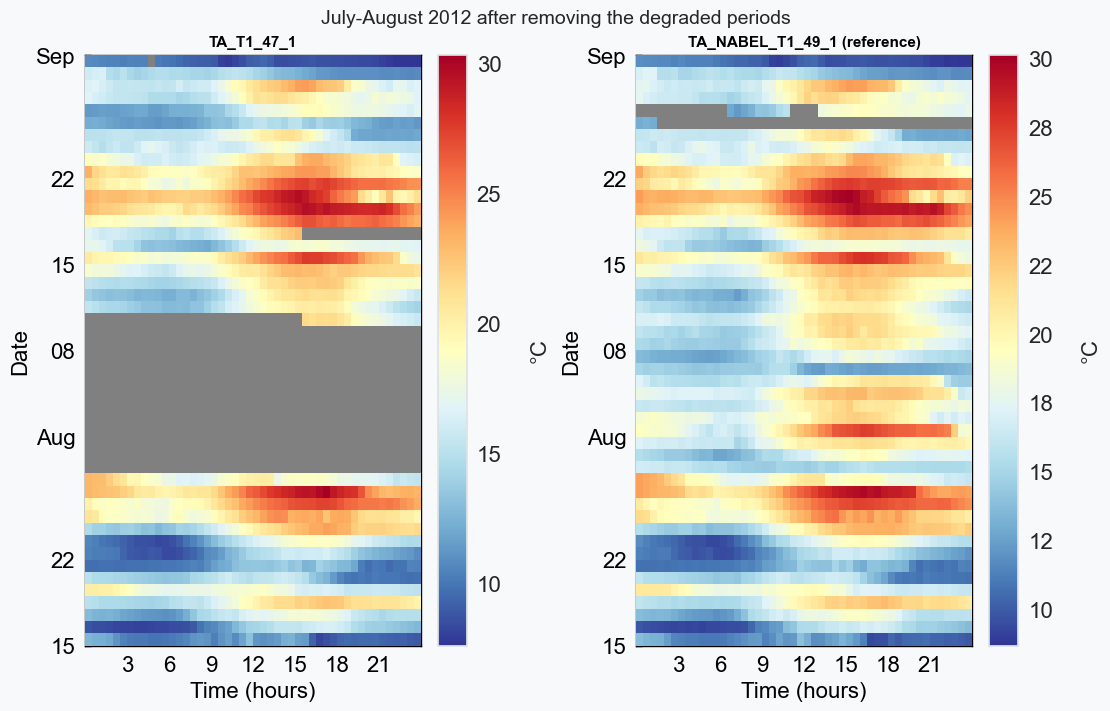

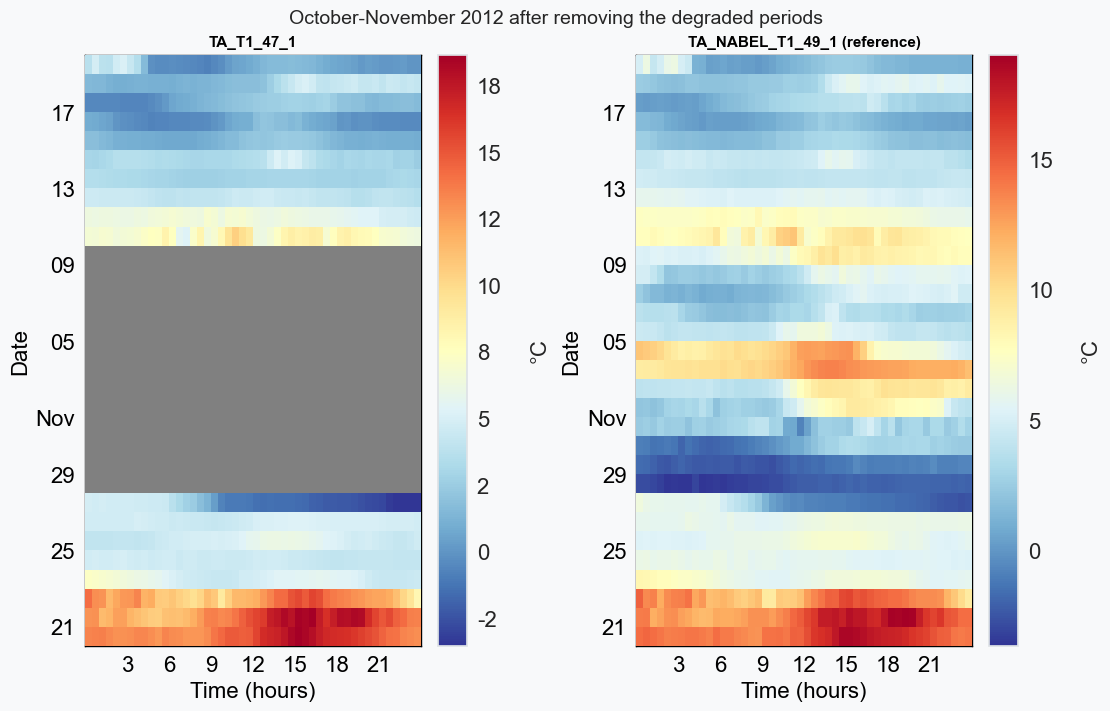

In [16]:
# Three damaged periods in 2012, all documented in the fieldbook and none repairable.
# Windows are on the CORRECTED time axis (i.e. after the +15.5 h shift above).
BAD_WINDOWS_2012 = [
    ('2012-07-29 00:00', '2012-08-10 15:30'),  # tower power supply failure (fieldbook 09.08.2012)
    ('2012-08-17 15:30', '2012-08-18 00:00'),  # transitional tail after the last shifted value
    ('2012-10-28 00:00', '2012-11-10 00:00'),  # storm damage, stressed cables (fieldbook 01./06.11.2012)
]
DEGRADED_VAR = 'TA_T1_47_1'

_before = int(ta_2004_2025[DEGRADED_VAR].notna().sum())
for _start, _end in BAD_WINDOWS_2012:
    _locs = (ta_2004_2025.index >= _start) & (ta_2004_2025.index <= _end)
    ta_2004_2025.loc[_locs, DEGRADED_VAR] = np.nan
_removed = _before - int(ta_2004_2025[DEGRADED_VAR].notna().sum())
print(f"Removed {_removed} degraded records from {DEGRADED_VAR} (gap-filled later from NABEL).")

# One heatmap pair per affected period, with the NABEL sensor as the reference.
for _lo, _hi, _label in [('2012-07-15', '2012-09-01', 'July-August'),
                         ('2012-10-20', '2012-11-20', 'October-November')]:
    fig, axs = plt.subplots(ncols=2, figsize=(11, 7), dpi=100, layout="constrained")
    fig.suptitle(f'{_label} 2012 after removing the degraded periods', fontsize=14)
    _show = (ta_2004_2025.index >= _lo) & (ta_2004_2025.index <= _hi)
    dv.plotting.HeatmapDateTime(series=ta_2004_2025.loc[_show, DEGRADED_VAR]).plot(
        ax=axs[0], cb_digits_after_comma=0, zlabel='°C',
        format_style=dv.plotting.FormatStyle(title=DEGRADED_VAR, title_fontsize=11))
    dv.plotting.HeatmapDateTime(series=ta_2004_2025.loc[_show, 'TA_NABEL_T1_49_1']).plot(
        ax=axs[1], cb_digits_after_comma=0, zlabel='°C',
        format_style=dv.plotting.FormatStyle(title='TA_NABEL_T1_49_1 (reference)', title_fontsize=11))

::: {.callout-note title="No zero-offset correction here"}
Notebook `01` removes a nighttime zero-offset from `SW_IN`. That correction is specific to
radiation sensors, which can read a small non-zero value at night when the true value is known to
be zero. Air temperature has no such reference value, so no equivalent step exists and none is
applied.
:::

## Dataframe

In [17]:
display(ta_2004_2025)
ta_2004_2025.describe()

,TA_T1_47_1,TA_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,-2.666667
2004-01-01 00:45:00,NaN,-2.566667
2004-01-01 01:15:00,NaN,-2.533333
2004-01-01 01:45:00,NaN,-2.633333
2004-01-01 02:15:00,NaN,-2.800000
...,...,...
2025-12-31 21:45:00,-3.081644,NaN
2025-12-31 22:15:00,-3.084372,NaN
2025-12-31 22:45:00,-3.423939,NaN


,TA_T1_47_1,TA_NABEL_T1_49_1
count,369065.000000,262403.000000
mean,8.954679,8.941020
std,8.163320,8.028659
min,-17.200001,-16.366667
25%,2.642000,2.633333
50%,8.870000,9.100000
75%,14.980000,14.966667
max,33.558765,33.066667


***

# 🟦 Drivers

Two drivers are added for the gap-filling:

- **Gap-filled `SW_IN`** from notebook `01`. It is complete over the whole record, so it is
  available as a driver in every year. Incoming radiation drives the daily temperature cycle,
  which makes it the most useful measured predictor available here.
- **`SW_IN_POT`**, potential radiation, computed from the site coordinates. It carries day length
  and season in a single continuous variable and never has gaps.

Notebook `01` has to be run before this one.

In [18]:
swin_gf = dv.load_parquet(filepath=str(Path(OUTPATH) / f"{SWIN_FILE}.parquet"))
print(f"Loaded {SWIN_FILE}: {list(swin_gf.columns)}")
print(f"  {swin_gf.index[0]} -> {swin_gf.index[-1]} ({len(swin_gf):,} records)")
swin_gf.head()

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\01_METEO
_SW_IN_GAPFILLED_2004-2025.parquet (0.442 seconds).

Loaded 01_METEO_SW_IN_GAPFILLED_2004-2025: ['SW_IN_T1_47_1_gfXG', 'FLAG_SW_IN_T1_47_1_ISFILLED']
  2004-01-01 00:15:00 -> 2025-12-31 23:45:00 (385,728 records)


,SW_IN_T1_47_1_gfXG,FLAG_SW_IN_T1_47_1_ISFILLED
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,0.0,3
2004-01-01 00:45:00,0.0,3
2004-01-01 01:15:00,0.0,3
2004-01-01 01:45:00,0.0,3
2004-01-01 02:15:00,0.0,3


In [19]:
# SW_IN_POT from the site coordinates.
swinpot = dv.variables.potrad(
    timestamp_index=ta_2004_2025.index,
    lat=SITE_LAT,
    lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
)

drivers = pd.DataFrame(index=ta_2004_2025.index)
drivers[SWIN_COL] = swin_gf[SWIN_COL]  # keeps the name it has in the file; aligned on the index
drivers['SW_IN_POT'] = swinpot

# Both drivers must be complete, otherwise records fall back to the timestamp-only model.
print(drivers.isnull().sum().rename('missing values'))
drivers.describe()

SW_IN_T1_47_1_gfXG    0
SW_IN_POT             0
Name: missing values, dtype: int64


,SW_IN_T1_47_1_gfXG,SW_IN_POT
count,385728.000000,385728.000000
mean,145.499029,298.951202
std,239.720112,382.633189
min,0.000000,0.000000
25%,0.000000,0.000000
50%,4.008015,17.494992
75%,196.845521,566.632430
max,1118.658439,1214.125501


***

# 🟪 Prepare dataframes

Split into the two periods that are gap-filled separately: the years where NABEL is available
as an additional driver, and the years where it is not. The cut-off is taken from the data rather
than hard-coded.

In [20]:
# Last year in which NABEL delivers a usable amount of data.
_nabel_per_year = ta_2004_2025['TA_NABEL_T1_49_1'].groupby(ta_2004_2025.index.year).count()
print("NABEL records per year:")
print(_nabel_per_year.to_string())
NABEL_LAST_YEAR = int(_nabel_per_year[_nabel_per_year > 0].index.max())
print(f"\nNABEL is used as driver up to and including {NABEL_LAST_YEAR}.")

NABEL records per year:
TIMESTAMP_MIDDLE
2004    17508
2005    17266
2006    17515
2007    17508
2008    17561
2009    17507
2010    17441
2011    17500
2012    17453
2013    17519
2014    17518
2015    17516
2016    17557
2017    17514
2018    17520
2019        0
2020        0
2021        0
2022        0
2023        0
2024        0
2025        0

NABEL is used as driver up to and including 2018.


In [21]:
ta_early = ta_2004_2025.loc[ta_2004_2025.index.year <= NABEL_LAST_YEAR].copy()
drivers_early = drivers.loc[drivers.index.year <= NABEL_LAST_YEAR].copy()
ta_early

,TA_T1_47_1,TA_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,-2.666667
2004-01-01 00:45:00,NaN,-2.566667
2004-01-01 01:15:00,NaN,-2.533333
2004-01-01 01:45:00,NaN,-2.633333
2004-01-01 02:15:00,NaN,-2.800000
...,...,...
2018-12-31 21:45:00,3.193911,3.193900
2018-12-31 22:15:00,3.021761,3.021733
2018-12-31 22:45:00,2.934472,2.934467


In [22]:
ta_late = ta_2004_2025.loc[ta_2004_2025.index.year > NABEL_LAST_YEAR].copy()
ta_late = ta_late.drop('TA_NABEL_T1_49_1', axis=1)
drivers_late = drivers.loc[drivers.index.year > NABEL_LAST_YEAR].copy()
ta_late

,TA_T1_47_1
TIMESTAMP_MIDDLE,
2019-01-01 00:15:00,2.666350
2019-01-01 00:45:00,2.475211
2019-01-01 01:15:00,2.278222
2019-01-01 01:45:00,2.280883
2019-01-01 02:15:00,2.138061
...,...
2025-12-31 21:45:00,-3.081644
2025-12-31 22:15:00,-3.084372
2025-12-31 22:45:00,-3.423939


***

# 🟥 Gap-filling

## Method

Notebook `01` uses `SWINGapFillerXGBoost`, which is built specifically for radiation: it sets
nighttime gaps to zero, clips negative predictions to zero, removes a nighttime sensor offset and
interpolates the clearness index `SW_IN/SW_IN_POT`. **None of that is valid for temperature** —
it would put 0 °C into every night-time gap and turn every frost gap into 0 °C.

This notebook therefore uses the general `XGBoostTS` gap-filler with an explicit
`FeatureEngineer`, which is what `SWINGapFillerXGBoost` wraps internally. Everything else follows
notebook `01`: the same drivers-plus-timestamp feature idea, SHAP-based feature reduction, and
short gaps filled by interpolation rather than by the model.

Four settings are worth understanding:

- **`features_lag=[]`.** The model only predicts records where every feature is present. A lag of
  a driver that has gaps turns "my neighbour is missing" into "I cannot be filled", which pushes
  records to the weaker timestamp-only fallback.
- **`SW_IN_POT` is excluded from the rolling and EMA stages.** It follows from the timestamp
  alone, so smoothed versions of it repeat what its raw value and the timestamp features already
  say. Including it added 14 features here and changed the score in the fourth decimal.
- **`shap_max_rows=10_000`.** SHAP importances are the slowest part of a run, they are computed
  four times per call (train, reduce, retrain, fill), and the cost grows with the number of rows
  and trees. The mean importances settle long before the full record is used, so the rows are
  capped — the same cap `SWINGapFillerXGBoost` applies. Predictions and scores are untouched;
  only the importances (and therefore the feature reduction) read the capped sample, which stays
  reproducible through `random_state`.
- **Hyperparameters are given explicitly.** Unlike `SWINGapFillerXGBoost`, the general `XGBoostTS`
  ships no tuned defaults, so the values that class uses for radiation are set here by hand.

**Short gaps** (up to 1 h) are filled by linear interpolation afterwards and flagged `4`. The
model never sees the target's own neighbours, because the feature engineer excludes the target
from its own features, so a short gap is exactly the case it is blind to. Unlike radiation,
temperature is continuous across midnight, so the interpolation is not restricted to single days
here.

In [23]:
SHAP_MAX_ROWS = 10_000  # rows used for SHAP importances, see the note above


def short_gap_mask(series: pd.Series, limit: int) -> pd.Series:
    """True where `series` is missing AND its whole gap is at most `limit` records long.

    Whole runs are selected explicitly. Using pandas' `interpolate(limit=)` instead would fill
    the first `limit` records of a long gap as well, which is not wanted: those values would sit
    on a straight line spanning the entire gap.
    """
    missing = series.isna()
    run_length = missing.groupby((~missing).cumsum()).transform('sum')
    return missing & (run_length <= limit)


def gapfill_ta(target: pd.Series,
               drivers: pd.DataFrame,
               interpolate_limit: int = 2,
               reduce_features: bool = True,
               verbose: int = 1):
    """Gap-fill a temperature series with XGBoost, then interpolate the remaining short gaps.

    Returns (model, gapfilled, flag). `gapfilled` carries the `_gfXG` name, `flag` follows
    FLAG_LEGEND.
    """
    input_df = pd.concat([target, drivers], axis=1)

    engineer = dv.gapfilling.FeatureEngineer(
        target_col=target.name,
        features_lag=[],  # see the note above
        features_rolling=[4, 8, 24, 48],  # 2h, 4h, 12h, 24h on 30MIN data
        features_rolling_stats=['median'],
        features_rolling_exclude_cols=['SW_IN_POT'],  # deterministic, see the note above
        features_ema=[6, 24],  # 3h, 12h
        features_ema_exclude_cols=['SW_IN_POT'],
        vectorize_timestamps=True,
        add_continuous_record_number=True,
        verbose=0,
    )
    features_df = engineer.fit_transform(input_df)
    print(f"Features: {features_df.shape[1] - 1} over {len(features_df):,} records")

    model = dv.gapfilling.XGBoostTS(
        input_df=features_df,
        target_col=target.name,
        verbose=verbose,
        shap_max_rows=SHAP_MAX_ROWS,
        n_estimators=3000,
        max_depth=6,
        early_stopping_rounds=20,
        random_state=42,
        n_jobs=-1,
    )
    model.trainmodel(showplot_scores=False, showplot_importance=False)
    if reduce_features:
        model.reduce_features()
        model.trainmodel(showplot_scores=False, showplot_importance=False)
    model.fillgaps(showplot_scores=False, showplot_importance=False)

    gapfilled = model.results.gapfilled.copy()
    flag = model.results.flag.copy()

    if interpolate_limit:
        short = short_gap_mask(target, interpolate_limit)
        interp = target.interpolate(method='time', limit_area='inside')
        fill_locs = short & interp.notna()
        gapfilled[fill_locs] = interp[fill_locs]
        flag[fill_locs] = 4
        print(f"Short-gap interpolation: {int(fill_locs.sum())} records")

    gapfilled = gapfilled.rename(f"{target.name}_gfXG")
    flag = flag.rename(f"FLAG_{target.name}_ISFILLED")
    return model, gapfilled, flag

## 🟥 Gap-filling NABEL

NABEL is filled first so that it is complete and can then serve as a driver for the ETH series.
Its own drivers are the ETH series plus `SW_IN_T1_47_1_gfXG` and `SW_IN_POT`.

In [24]:
%%time

TARGET = "TA_NABEL_T1_49_1"

_drivers = pd.concat([ta_early[['TA_T1_47_1']], drivers_early], axis=1)
gf_nabel, gapfilled_nabel, flag_nabel = gapfill_ta(
    target=ta_early[TARGET],
    drivers=_drivers,
)

Features: 46 over 262,992 records


! Some features are incomplete (<262992 values): TA_T1_47_1 (247204), .TA_T1_47_1_MEAN4 (247413), 
.TA_T1_47_1_SD4 (247413), .TA_T1_47_1_MEAN8 (247455), .TA_T1_47_1_SD8 (247455), .TA_T1_47_1_MEAN24 
(247587), .TA_T1_47_1_SD24 (247587), .TA_T1_47_1_MEAN48 (247732), .TA_T1_47_1_SD48 (247732), 
.TA_T1_47_1_ROLLMEDIAN4 (247413), .TA_T1_47_1_ROLLMEDIAN8 (247455), .TA_T1_47_1_ROLLMEDIAN24 
(247587), .TA_T1_47_1_ROLLMEDIAN48 (247732), .TA_T1_47_1_EMA6 (250347), .TA_T1_47_1_EMA24 (250347)

! Not all target values can be predicted based on the full model.

> ++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', 
'.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', 
'.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] (ONLY 
FALLBACK)

Short-gap interpolation: 43 records
CPU times: total: 18min 3s
Wall time: 2min 33s


## Results: scores and feature importances

In [25]:
print("Held-out (train/test) scores:")
display(pd.Series(gf_nabel.results.scores_traintest))
print("Flag counts:")
display(flag_nabel.value_counts().sort_index().rename(index=FLAG_LEGEND))

Held-out (train/test) scores:


mae      1.434364e-01
medae    1.014076e-01
mse      4.304192e-02
rmse     2.074655e-01
mape     7.995224e+11
maxe     2.716774e+00
r2       9.993280e-01
dtype: float64

Flag counts:


FLAG_TA_NABEL_T1_49_1_ISFILLED
0 = observed                                                                  262403
1 = gap-filled by the XGBoost model                                              504
2 = gap-filled by the timestamp-only fallback model (a driver was missing)        42
4 = gap-filled by linear interpolation (short gap)                                43
Name: count, dtype: int64

In [26]:
gf_nabel.results.feature_importances

,SHAP_IMPORTANCE,SHAP_SD
TA_T1_47_1,5.741802,3.702505
.TA_T1_47_1_EMA6,0.753627,0.457349
.YEAR,0.369352,0.281877
.TA_T1_47_1_MEAN4,0.205752,0.160691
SW_IN_T1_47_1_gfXG,0.120811,0.076826
...,...,...
.TA_T1_47_1_SD48,0.016821,0.017192
.WEEK_SIN,0.016818,0.019390
.WEEK_COS,0.016409,0.017717
.TA_T1_47_1_MEAN24,0.014960,0.016227


## Add gap-filled series to dataframe

In [27]:
ta_early[gapfilled_nabel.name] = gapfilled_nabel
ta_early[[TARGET, gapfilled_nabel.name]].describe()

,TA_NABEL_T1_49_1,TA_NABEL_T1_49_1_gfXG
count,262403.000000,262992.000000
mean,8.941020,8.943870
std,8.028659,8.032811
min,-16.366667,-16.366667
25%,2.633333,2.633333
50%,9.100000,9.100000
75%,14.966667,14.966667
max,33.066667,33.066667


***

# 🟥 Gap-filling ETH (NABEL years)

The gap-filled NABEL series is now complete and is used as an additional driver, together with
`SW_IN_T1_47_1_gfXG` and `SW_IN_POT`.

In [28]:
%%time

TARGET = "TA_T1_47_1"

_drivers = pd.concat([ta_early[['TA_NABEL_T1_49_1_gfXG']], drivers_early], axis=1)
gf_eth_early, gapfilled_eth_early, flag_eth_early = gapfill_ta(
    target=ta_early[TARGET],
    drivers=_drivers,
)

Features: 46 over 262,992 records
Short-gap interpolation: 170 records
CPU times: total: 17min 58s
Wall time: 2min 30s


## Results: scores and feature importances

In [29]:
print("Held-out (train/test) scores:")
display(pd.Series(gf_eth_early.results.scores_traintest))
print("Flag counts:")
display(flag_eth_early.value_counts().sort_index().rename(index=FLAG_LEGEND))

Held-out (train/test) scores:


mae      1.424116e-01
medae    9.780407e-02
mse      4.378981e-02
rmse     2.092601e-01
mape     1.908540e+10
maxe     2.939945e+00
r2       9.993450e-01
dtype: float64

Flag counts:


FLAG_TA_T1_47_1_ISFILLED
0 = observed                                          247204
1 = gap-filled by the XGBoost model                    15618
4 = gap-filled by linear interpolation (short gap)       170
Name: count, dtype: int64

In [30]:
gf_eth_early.results.feature_importances

,SHAP_IMPORTANCE,SHAP_SD
TA_NABEL_T1_49_1_gfXG,6.356194,4.118166
.YEAR,0.430888,0.318504
.TA_NABEL_T1_49_1_gfXG_ROLLMEDIAN4,0.318328,0.206442
SW_IN_T1_47_1_gfXG,0.224157,0.152249
.TA_NABEL_T1_49_1_gfXG_MEAN4,0.112802,0.095738
...,...,...
.TA_NABEL_T1_49_1_gfXG_SD48,0.017427,0.017021
.SW_IN_T1_47_1_gfXG_SD8,0.016606,0.014005
.TA_NABEL_T1_49_1_gfXG_SD24,0.016430,0.018536
.TA_NABEL_T1_49_1_gfXG_SD4,0.016378,0.018067


## Add gap-filled series to dataframe

In [31]:
ta_early[gapfilled_eth_early.name] = gapfilled_eth_early
ta_early[[TARGET, gapfilled_eth_early.name]].describe()

,TA_T1_47_1,TA_T1_47_1_gfXG
count,247204.000000,262992.000000
mean,8.267731,8.305272
std,8.194155,8.203259
min,-17.200001,-17.200001
25%,1.907000,1.906000
50%,8.300000,8.374846
75%,14.300000,14.400000
max,32.650002,32.650002


## Heatmap

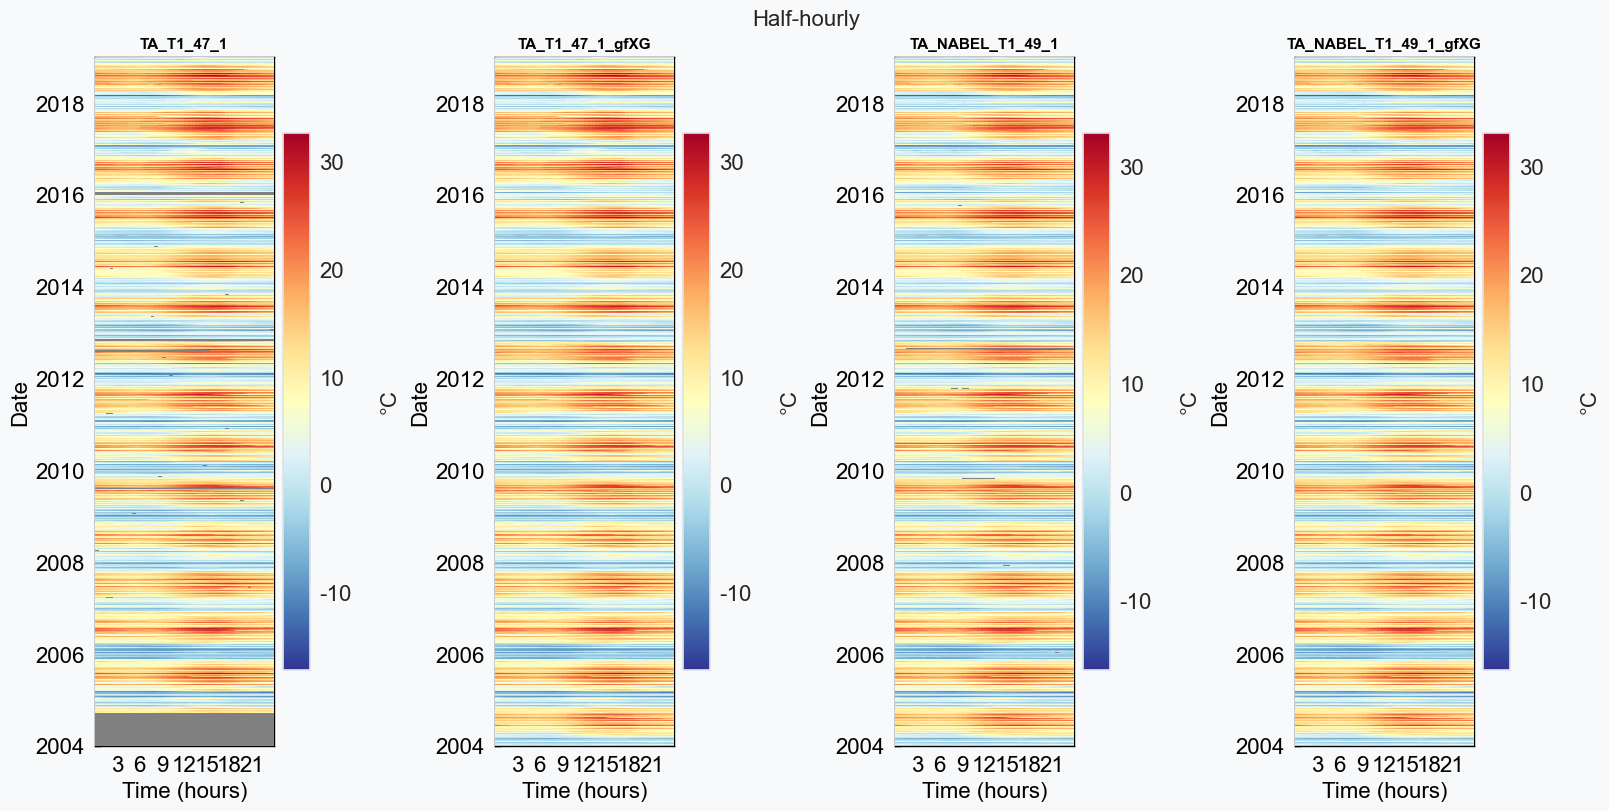

In [32]:
fig, axs = plt.subplots(ncols=4, figsize=(16, 8), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
for ax, col in zip(axs, ['TA_T1_47_1', 'TA_T1_47_1_gfXG',
                         'TA_NABEL_T1_49_1', 'TA_NABEL_T1_49_1_gfXG']):
    dv.plotting.HeatmapDateTime(series=ta_early[col]).plot(
        ax=ax, cb_digits_after_comma=0, zlabel='°C',
        format_style=dv.plotting.FormatStyle(title=col, title_fontsize=11))

***

# 🟧 Gap-filling ETH (years without NABEL)

No NABEL data in this period. Unlike the equivalent step in notebook `01`, this is **not** a
timestamp-only fill: the gap-filled `SW_IN` from notebook `01` is complete and is available as a
driver here too, so the model still sees a measured variable that carries the actual weather.

In [33]:
%%time

TARGET = "TA_T1_47_1"

gf_eth_late, gapfilled_eth_late, flag_eth_late = gapfill_ta(
    target=ta_late[TARGET],
    drivers=drivers_late,
)

Features: 31 over 122,736 records
Short-gap interpolation: 8 records
CPU times: total: 20min 1s
Wall time: 2min 49s


## Results: scores and feature importances

In [34]:
print("Held-out (train/test) scores:")
display(pd.Series(gf_eth_late.results.scores_traintest))
print("Flag counts:")
display(flag_eth_late.value_counts().sort_index().rename(index=FLAG_LEGEND))

Held-out (train/test) scores:


mae      0.474235
medae    0.335230
mse      0.442483
rmse     0.665194
mape     0.625225
maxe     5.114078
r2       0.992978
dtype: float64

Flag counts:


FLAG_TA_T1_47_1_ISFILLED
0 = observed                                          121861
1 = gap-filled by the XGBoost model                      867
4 = gap-filled by linear interpolation (short gap)         8
Name: count, dtype: int64

In [35]:
gf_eth_late.results.feature_importances

,SHAP_IMPORTANCE,SHAP_SD
.DOY_COS,2.434731,1.468015
.WEEK_COS,2.101059,0.850560
.SW_IN_T1_47_1_gfXG_EMA24,1.547156,0.968624
.DOY_SIN,1.537888,1.030612
.SW_IN_T1_47_1_gfXG_MEAN48,0.989058,0.718062
.RECORDNUMBER,0.704258,0.589323
.YEARWEEK,0.682353,0.536238
.SW_IN_T1_47_1_gfXG_SD48,0.659053,0.536886
.SEASON_SIN,0.569712,0.415812
.SW_IN_T1_47_1_gfXG_ROLLMEDIAN48,0.549917,0.402223


## Add gap-filled series to dataframe

In [36]:
ta_late[gapfilled_eth_late.name] = gapfilled_eth_late
ta_late[[TARGET, gapfilled_eth_late.name]].describe()

,TA_T1_47_1,TA_T1_47_1_gfXG
count,121861.000000,122736.000000
mean,10.348204,10.333655
std,7.919468,7.898905
min,-11.956045,-11.956045
25%,4.325922,4.367937
50%,9.975467,9.919578
75%,16.329861,16.295732
max,33.558765,33.558765


***

# ➡️ Prepare dataframe for export

In [37]:
VALCOL = "TA_T1_47_1_gfXG"
FLAGCOL = "FLAG_TA_T1_47_1_ISFILLED"

# Values and flags come from the same gap-filling run per period, so they are paired
# before the two periods are stacked.
export_df = pd.concat([
    pd.concat([ta_early[VALCOL], flag_eth_early], axis=1),
    pd.concat([ta_late[VALCOL], flag_eth_late], axis=1),
], axis=0)
export_df

,TA_T1_47_1_gfXG,FLAG_TA_T1_47_1_ISFILLED
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,-3.312291,1
2004-01-01 00:45:00,-3.334407,1
2004-01-01 01:15:00,-3.218955,1
2004-01-01 01:45:00,-3.328506,1
2004-01-01 02:15:00,-3.315091,1
...,...,...
2025-12-31 21:45:00,-3.081644,0
2025-12-31 22:15:00,-3.084372,0
2025-12-31 22:45:00,-3.423939,0


Sanity check: the exported series must be complete (no gaps), the index must be continuous
30MIN with no duplicates, and every record must carry a flag. Unlike `SW_IN` there is no
non-negativity check — air temperature is negative for a good part of the year.

`FLAG_TA_T1_47_1_ISFILLED` travels with the product so the downstream notebooks can tell measured
from filled records. Flag `0` is measured, everything above `0` is filled by the method given in
`FLAG_LEGEND`.

In [38]:
print(f"Records:         {len(export_df)}")
print(f"Missing values:  {export_df[VALCOL].isnull().sum()}")
print(f"Missing flags:   {export_df[FLAGCOL].isnull().sum()}")
print(f"Duplicate index: {export_df.index.duplicated().sum()}")
print(f"Index gaps:      {(export_df.index.to_series().diff().dropna() != pd.Timedelta('30min')).sum()}")
print(f"Min / max:       {export_df[VALCOL].min():.2f} / {export_df[VALCOL].max():.2f} degC")

print("\nFill provenance:")
_counts = export_df[FLAGCOL].value_counts().sort_index()
_pct = 100 * _counts / len(export_df)
display(pd.DataFrame({'count': _counts, '%': _pct.round(2)}).rename(index=FLAG_LEGEND))
print(f"Measured: {100 * (export_df[FLAGCOL] == 0).mean():.2f}%  |  "
      f"Filled: {100 * (export_df[FLAGCOL] > 0).mean():.2f}%")

export_df.describe()

Records:         385728
Missing values:  0
Missing flags:   0
Duplicate index: 0
Index gaps:      0
Min / max:       -17.20 / 33.56 degC

Fill provenance:


,count,%
FLAG_TA_T1_47_1_ISFILLED,,
0 = observed,369065,95.68
1 = gap-filled by the XGBoost model,16485,4.27
4 = gap-filled by linear interpolation (short gap),178,0.05


Measured: 95.68%  |  Filled: 4.32%


,TA_T1_47_1_gfXG,FLAG_TA_T1_47_1_ISFILLED
count,385728.000000,385728.000000
mean,8.950689,0.044583
std,8.162505,0.219393
min,-17.200001,0.000000
25%,2.619000,0.000000
50%,8.890000,0.000000
75%,15.000000,0.000000
max,33.558765,4.000000


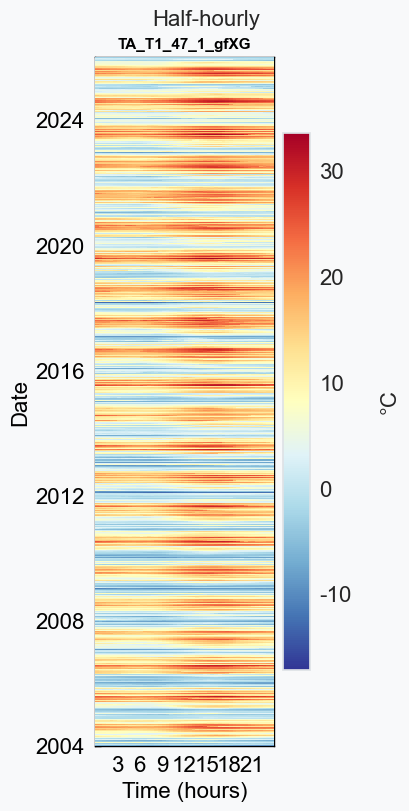

In [39]:
fig, axs = plt.subplots(ncols=1, figsize=(4, 8), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.plotting.HeatmapDateTime(series=export_df[VALCOL]).plot(
    ax=axs, cb_digits_after_comma=0, zlabel='°C',
    format_style=dv.plotting.FormatStyle(title=VALCOL, title_fontsize=11))

***

# 💾 Save to file

In [40]:
filepath = dv.save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
export_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")
print(f"Saved to: {filepath}")

> Saved file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\02_METEO
_TA_GAPFILLED_2004-2025.parquet (0.054 seconds).

Saved to: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\02_METEO_TA_GAPFILLED_2004-2025.parquet


***

# End of notebook.

In [41]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h:02d}:{_m:02d}:{_s:02d} (hh:mm:ss)")

Started:  2026-07-19 23:27:25
Finished: 2026-07-19 23:35:52
Runtime:  00:08:26 (hh:mm:ss)
